## Exercise: Colonel Blotto
From the paper "An Introduction to Counterfactual Regret Minimization" by Todd W. Neller and Marc Lanctot, Section 2.6.

In [1]:
import numpy as np

np.random.seed(4)  # For reproducibility

In [2]:
# unique IDs for each action of distributing S soldiers across N battlefields
N = 3  # number of battlefields
S = 5  # number of soldiers

def generate_strategies(S, N):
    """
    Generate all unique strategies for distributing S soldiers across N battlefields.
    Each strategy is represented as a list of length N, where each element indicates
    the number of soldiers allocated to that battlefield.
    """
    def recurse(battlefield_index, soldiers_remaining, current_row_partial_allocation, output_list):
        if battlefield_index == N - 1:
            current_row_partial_allocation[battlefield_index] = soldiers_remaining
            output_list.append(current_row_partial_allocation.copy())
            return
        for i in range(soldiers_remaining + 1):
            current_row_partial_allocation[battlefield_index] = i
            recurse(battlefield_index + 1, soldiers_remaining - i, current_row_partial_allocation, output_list)

    output_list = []
    recurse(0, S, np.zeros(N), output_list)

    strategies = np.array(output_list)

    return strategies

generate_strategies(S, N).shape

(21, 3)

In [3]:
def utility_matrix(strategies):
    """
    Compute the utility matrix for the Colonel Blotto game given the strategies.
    The utility is calculated based on the number of battlefields won by each player.
    """
    num_strategies = strategies.shape[0]
    utility = np.zeros((num_strategies, num_strategies))

    for i in range(num_strategies):
        for j in range(num_strategies):
            # Count the number of battlefields won by player 1
            wins_player1 = np.sum(strategies[i] > strategies[j])
            wins_player2 = np.sum(strategies[i] < strategies[j])
            if wins_player1 > wins_player2:
                utility[i, j] = 1  # Player 1 wins
            elif wins_player1 < wins_player2:
                utility[i, j] = -1  # Player 2 wins
            else:
                utility[i, j] = 0  # Tie

    return utility

In [4]:
# get strategy based on regret sum
def get_strategy(regret_sum, strategy_sum):
    """
    Compute the current strategy based on the regret sum.
    The strategy is normalized to ensure it sums to 1.
    """
    strategy = np.maximum(regret_sum, 0)
    normalizing_sum = np.sum(strategy)
    if normalizing_sum > 0:
        strategy /= normalizing_sum
    else:
        strategy = np.ones_like(regret_sum) / len(regret_sum)  # uniform distribution if no positive regrets
    strategy_sum += strategy
    return strategy

In [5]:
def get_action(strategy):
    """
    Sample an action based on the current strategy.
    The action is chosen according to the probabilities defined by the strategy.
    """
    return np.random.choice(len(strategy), p=strategy)

In [6]:
strategies = generate_strategies(S, N)
U_matrix = utility_matrix(strategies)

In [7]:
def train_two_player(iterations, log_every=1_000):

    strategies_num = strategies.shape[0]
    regret_sum_p1 = np.zeros(strategies_num)
    strategy_sum_p1 = np.zeros(strategies_num)
    regret_sum_p2 = np.zeros(strategies_num)
    strategy_sum_p2 = np.zeros(strategies_num)

    history_p1, history_p2 = [], []
    
    for i in range(iterations):
        strat1 = get_strategy(regret_sum_p1, strategy_sum_p1)
        strat2 = get_strategy(regret_sum_p2, strategy_sum_p2)

        a1 = get_action(strat1)
        a2 = get_action(strat2)

        util1 = U_matrix[:, a2]       # p1's utility for each action, given p2 played a2
        util2 = -U_matrix[a1, :]      # p2's utility for each action, given p1 played a1

        regret_sum_p1 += util1 - util1[a1]
        regret_sum_p2 += util2 - util2[a2]

        if i % log_every == 0:
            history_p1.append((strategy_sum_p1 / max(strategy_sum_p1.sum(), 1e-12)).copy())
            history_p2.append((strategy_sum_p2 / max(strategy_sum_p2.sum(), 1e-12)).copy())

    return np.array(history_p1), np.array(history_p2)

In [8]:
steps = 5_000
h1, h2 = train_two_player(1_000_000, log_every=steps)

## plotting

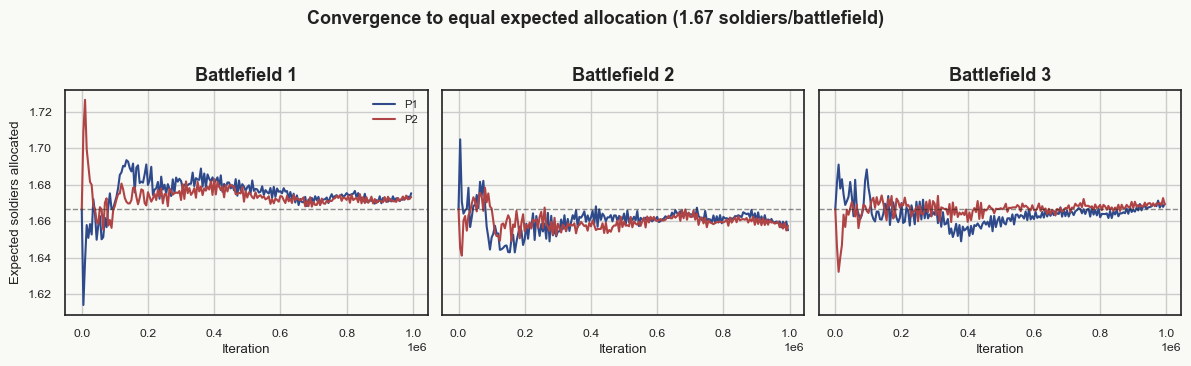

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

OFF_WHITE = "#F9F9F6"
INK = "#222222"
BLUE = "#2F4A8A"
RED = "#B04444"

sns.set_theme(style="whitegrid", font_scale=0.8,
              rc={'figure.facecolor': OFF_WHITE, 'axes.facecolor': OFF_WHITE})

# h1, h2 are your existing (n_checkpoints, 21) average-strategy histories
# convert each to expected soldiers-per-battlefield: weighted sum over strategies
expected_alloc_p1 = h1 @ strategies   # shape (n_checkpoints, N)
expected_alloc_p2 = h2 @ strategies

iters = np.arange(len(h1)) * steps
target = S / N  # 5/3

fig, axes = plt.subplots(1, N, figsize=(4 * N, 3.5), sharey=True, facecolor=OFF_WHITE)

for k in range(N):
    ax = axes[k]
    ax.set_facecolor(OFF_WHITE)
    ax.plot(iters, expected_alloc_p1[:, k], color=BLUE, linewidth=1.5, label="P1")
    ax.plot(iters, expected_alloc_p2[:, k], color=RED, linewidth=1.5, label="P2")
    ax.axhline(target, color=INK, linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(f"Battlefield {k+1}", fontsize=13, fontweight="bold", color=INK)
    ax.set_xlabel("Iteration", color=INK)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(1.2); spine.set_color(INK)

axes[0].set_ylabel("Expected soldiers allocated", color=INK)
axes[0].legend(frameon=False, fontsize=8)

fig.suptitle(f"Convergence to equal expected allocation ({target:.2f} soldiers/battlefield)",
             fontsize=13, fontweight="bold", color=INK, y=1.03)

plt.tight_layout()
plt.show()